In [1]:
# Import
import ee
import geemap
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import requests
from PIL import Image
from io import BytesIO
from IPython.display import display, HTML

def show_map(m):
    """Reliably display a geemap Map in Codespaces."""
    try:
        display(m)
    except Exception:
        display(HTML(m.to_html()))

print("✅ All imports successful!")

✅ All imports successful!


In [2]:
# Authenticate
ee.Authenticate()

True

In [3]:
# Initialize
PROJECT_ID = 'ee-xinranzhou2059'   # ⚠️ replace this

ee.Initialize(project=PROJECT_ID)
print(f"✅ Earth Engine initialized — project: {PROJECT_ID}")

✅ Earth Engine initialized — project: ee-xinranzhou2059


In [4]:
lat_north = 40.7666667
lat_south = 39.4833333
lon_west = -105.4666667
lon_east = -105.05



study_area = ee.Geometry.Rectangle([
[lon_west, lat_south], # SW
[lon_east, lat_north] # NE
])



Map = geemap.Map(center=[(lat_north+lat_south)/2, (lon_west+lon_east)/2], zoom=9)
Map.addLayer(study_area, {'color': 'red'}, 'Study Area Rectangle')
Map

Map(center=[40.125, -105.25833335], controls=(WidgetControl(options=['position', 'transparent_bg'], position='…

In [5]:
nlcd_2001 = (ee.ImageCollection('USGS/NLCD_RELEASES/2019_REL/NLCD')
             .filter(ee.Filter.eq('system:index', '2001'))
             .first().select('landcover').clip(study_area))

nlcd_2021 = (ee.ImageCollection('USGS/NLCD_RELEASES/2021_REL/NLCD')
             .filter(ee.Filter.eq('system:index', '2021'))
             .first().select('landcover').clip(study_area))

# GEE knows NLCD's color palette — no vis_params needed
Map5 = geemap.Map(center=[(lat_north + lat_south) / 2, (lon_west + lon_east) / 2], zoom=14)
Map5.split_map(
    left_layer=geemap.ee_tile_layer(nlcd_2001, {}, 'NLCD 2001'),
    right_layer=geemap.ee_tile_layer(nlcd_2021, {}, 'NLCD 2021')
)
Map5.add_legend(title='NLCD Land Cover', builtin_legend='NLCD')
show_map(Map5)

Map(center=[40.125, -105.25833335], controls=(ZoomControl(options=['position', 'zoom_in_text', 'zoom_in_title'…

In [6]:
def apply_scale_factors(image):
    """Convert raw Landsat C2 L2 integers to surface reflectance (0–1)."""
    optical = image.select('SR_B.*').multiply(0.0000275).add(-0.2)
    thermal = image.select('ST_B.*').multiply(0.00341802).add(149.0)
    return image.addBands(optical, overwrite=True) \
                .addBands(thermal, overwrite=True)

landsat_2024 = (
    ee.ImageCollection('LANDSAT/LC08/C02/T1_L2')
    .merge(ee.ImageCollection('LANDSAT/LC09/C02/T1_L2'))
    .filterBounds(study_area)
    .filterDate('2024-06-01', '2024-08-31')
    .filter(ee.Filter.lt('CLOUD_COVER', 10))
    .map(apply_scale_factors)
    .median()
    .clip(study_area)
)

# Define visualization parameters for the blended RGB uint8 images
uint8_rgb_vis = {'bands': ['red', 'green', 'blue'], 'min': 0, 'max': 255}

# Prepare Landsat 2024 true color image with 'red', 'green', 'blue' bands.
# This ensures consistency for blending and final display.
landsat_2024_rgb = landsat_2024.select(

    ['SR_B4', 'SR_B3', 'SR_B2'],  # Original Landsat 8/9 bands for True Color
    ['red', 'green', 'blue']      # Renamed bands for consistent visualization
)

In [7]:
nlcd_change = nlcd_2001.select('landcover').neq(nlcd_2021.select('landcover'))
nlcd_change_reclassified = nlcd_change.remap([0, 1], [0, 1])

# Black for unchanged, red for changed
change_vis_combined = {'min': 0, 'max': 1, 'palette': ['000000', 'FF0000']}

Map_nlcd_change = geemap.Map(center=[(lat_north + lat_south) / 2, (lon_west + lon_east) / 2], zoom=9)

Map_nlcd_change.addLayer(landsat_2024_rgb, uint8_rgb_vis, 'Landsat 2024 True Color')
Map_nlcd_change.addLayer(nlcd_change_reclassified, change_vis_combined, 'NLCD Land Cover Change (2001-2021)')

# Legend
legend_dict = {
    'Unchanged': '#000000',
    'Changed': '#FF0000',
}

Map_nlcd_change.add_legend(legend_dict=legend_dict, title='Land Cover Status')

show_map(Map_nlcd_change)
Map_nlcd_change.to_html('nlcd_map_change.html')

Map(center=[40.125, -105.25833335], controls=(WidgetControl(options=['position', 'transparent_bg'], position='…

In [8]:
import os

# Load MODIS burned area data for the entire period 2001-2021
burned_area_2001_2021 = (ee.ImageCollection('MODIS/061/MCD64A1')
                            .filterDate('2001-01-01', '2021-12-31')
                            .select('BurnDate')
                            .max()
                            .gt(0)
                            .selfMask()
                            .clip(study_area))

# Calculate and print the total number of burned pixels for the period
pixel_count_2001_2021 = burned_area_2001_2021.reduceRegion(
    reducer=ee.Reducer.sum(),
    geometry=study_area,
    scale=500,
    maxPixels=1e9
).get('BurnDate').getInfo()

print(f"Burned pixels from 2001-2021 (MODIS): {pixel_count_2001_2021 if pixel_count_2001_2021 else 0}")

# Define visualization parameters for burned areas - ORANGE
fire_vis = {'palette': ['FFA500'], 'opacity': 0.7}

# Define border style for study area
border_vis = {
    'color': '000000',
    'width': 2,
    'fillColor': '00000000'
}

# Create map
Map_fire_aggregated = geemap.Map(center=[(lat_north + lat_south) / 2, (lon_west + lon_east) / 2], zoom=9)
Map_fire_aggregated.add_basemap('OpenStreetMap.Mapnik')

# Add study area border
Map_fire_aggregated.addLayer(study_area, border_vis, 'Study Area Boundary')

# Add burned areas overlay
Map_fire_aggregated.addLayer(burned_area_2001_2021, fire_vis, 'Burned Area 2001-2021')

# Legend
legend_dict = {'Burned Area': '#FFA500', 'Study Area Boundary': '#000000'}
Map_fire_aggregated.add_legend(legend_dict=legend_dict, title='Burned Area 2001-2021')

# Display ONLY the interactive map
Map_fire_aggregated.to_html('nlcd_map_change.html')
display(Map_fire_aggregated)

Burned pixels from 2001-2021 (MODIS): 3072.996078431373


Map(center=[40.125, -105.25833335], controls=(WidgetControl(options=['position', 'transparent_bg'], position='…

Burned pixels from 2001-2021 (MODIS): 3072.996078431373


Map(center=[40.125, -105.25833335], controls=(WidgetControl(options=['position', 'transparent_bg'], position='…

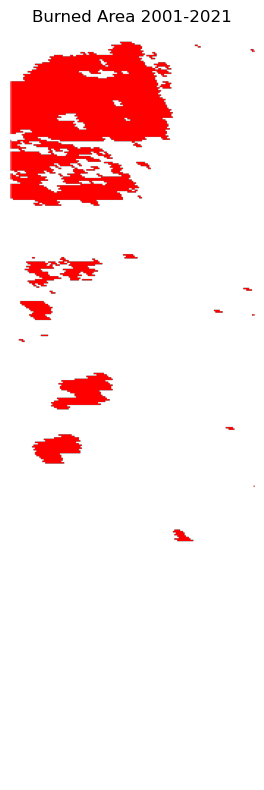

✅ Saved → figures/burned_area_2001_2021.png


In [9]:
import os

def get_ee_thumbnail(image, vis_params, region, size=512):
    """Fetch a GEE image as a PIL Image for matplotlib/savefig."""
    params = {**vis_params, 'region': region.getInfo(),
              'dimensions': size, 'format': 'png'}
    url = image.getThumbURL(params)
    return Image.open(BytesIO(requests.get(url).content))

# Load MODIS burned area data for the entire period 2001-2021
burned_area_2001_2021 = (ee.ImageCollection('MODIS/061/MCD64A1')
                            .filterDate('2001-01-01', '2021-12-31')
                            .select('BurnDate')
                            .max() # Use max to get any burn within the period
                            .gt(0)
                            .selfMask()
                            .clip(study_area))

# Calculate and print the total number of burned pixels for the period
pixel_count_2001_2021 = burned_area_2001_2021.reduceRegion(
    reducer=ee.Reducer.sum(),
    geometry=study_area,
    scale=500, # MODIS resolution is 500m
    maxPixels=1e9
).get('BurnDate').getInfo()

print(f"Burned pixels from 2001-2021 (MODIS): {pixel_count_2001_2021 if pixel_count_2001_2021 else 0}")

# Define visualization parameters for burned areas (red)
fire_vis = {'palette': ['ff0000']}

# Create a map to display aggregated burned areas
Map_fire_aggregated = geemap.Map(center=[(lat_north + lat_south) / 2, (lon_west + lon_east) / 2], zoom=9)
Map_fire_aggregated.addLayer(burned_area_2001_2021, fire_vis, 'Burned Area 2001-2021')

# Add a legend for the fire data
Map_fire_aggregated.add_legend(title='Burned Area', legend_keys=['Burned'], legend_colors=['#ff0000'])

show_map(Map_fire_aggregated)

# Save the map as a static image
fire_thumb_aggregated = get_ee_thumbnail(burned_area_2001_2021, fire_vis, study_area)

fig, ax = plt.subplots(1, 1, figsize=(8, 8))
ax.imshow(fire_thumb_aggregated)
ax.set_title('Burned Area 2001-2021')
ax.axis('off')
plt.tight_layout()

output_dir = 'figures'
os.makedirs(output_dir, exist_ok=True)
plt.savefig(os.path.join(output_dir, 'burned_area_2001_2021.png'), dpi=300, bbox_inches='tight')
plt.show()
print('✅ Saved → figures/burned_area_2001_2021.png')

In [10]:
def count_classes(nlcd_image, year):
    """Return a dict of {class_code: pixel_count} for an NLCD image."""
    result = nlcd_image.reduceRegion(
        reducer=ee.Reducer.frequencyHistogram(),
        geometry=study_area, scale=30, maxPixels=1e9
    ).getInfo()
    counts = result['landcover']
    print(f"\n--- NLCD {year} (top classes) ---")
    for code, n in sorted(counts.items(), key=lambda x: -x[1])[:8]:
        print(f"  Class {code}: {n:,} pixels")
    return counts

counts_2001 = count_classes(nlcd_2001, 2001)
counts_2021 = count_classes(nlcd_2021, 2021)


--- NLCD 2001 (top classes) ---
  Class 42: 2,167,103.156862742 pixels
  Class 52: 1,012,100.7294117649 pixels
  Class 71: 851,773.6039215686 pixels
  Class 22: 364,883.6039215686 pixels
  Class 21: 278,222.65490196075 pixels
  Class 82: 221,813.87058823527 pixels
  Class 23: 212,638.86274509807 pixels
  Class 11: 104,948.72156862744 pixels

--- NLCD 2021 (top classes) ---
  Class 42: 1,744,347.5215686248 pixels
  Class 52: 1,135,103.454901961 pixels
  Class 71: 1,041,375.8549019608 pixels
  Class 22: 391,609.84705882345 pixels
  Class 21: 327,438.79215686274 pixels
  Class 23: 272,557.1725490197 pixels
  Class 82: 192,132.79215686268 pixels
  Class 11: 111,299.70588235295 pixels


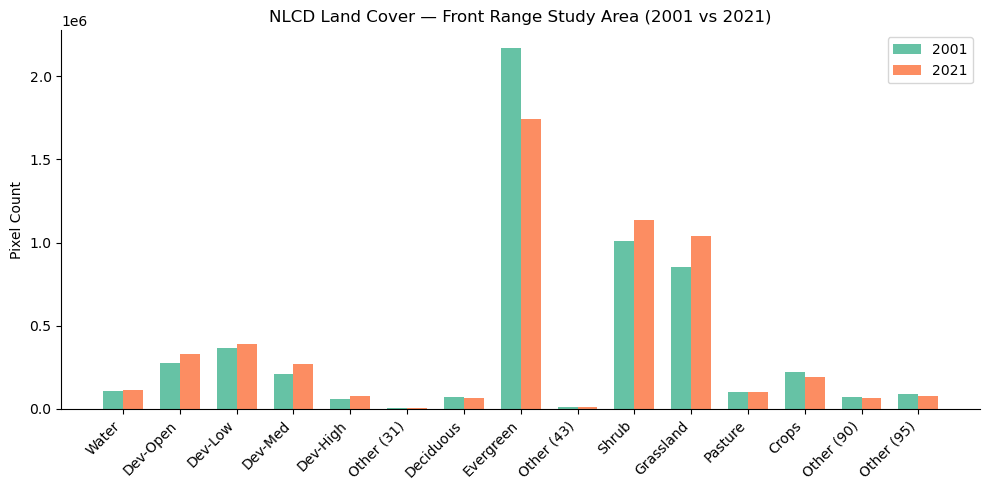

✅ Saved → figures/csu_nlcd_comparison.png


In [11]:
import pandas as pd

# Bar chart: 2001 vs 2021 side by side
nlcd_names = {
    '11':'Water','21':'Dev-Open','22':'Dev-Low','23':'Dev-Med','24':'Dev-High',
    '41':'Deciduous','42':'Evergreen','52':'Shrub','71':'Grassland',
    '81':'Pasture','82':'Crops'
}
all_classes = sorted(set(counts_2001) | set(counts_2021))
df = pd.DataFrame({
    'Class': [nlcd_names.get(c, f'Other ({c})') for c in all_classes],
    '2001':  [counts_2001.get(c, 0) for c in all_classes],
    '2021':  [counts_2021.get(c, 0) for c in all_classes],
})

fig, ax = plt.subplots(figsize=(10, 5))
x, w = range(len(df)), 0.35
ax.bar([i - w/2 for i in x], df['2001'], w, label='2001', color='#66c2a5')
ax.bar([i + w/2 for i in x], df['2021'], w, label='2021', color='#fc8d62')
ax.set_xticks(x); ax.set_xticklabels(df['Class'], rotation=45, ha='right')
ax.set_ylabel('Pixel Count')
ax.set_title('NLCD Land Cover — Front Range Study Area (2001 vs 2021)')
ax.legend(); ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig('figures/csu_nlcd_comparison.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Saved → figures/csu_nlcd_comparison.png")

In [12]:
# ✏️ largest increase and decrease
delta_counts = {cls: counts_2021.get(cls, 0) - counts_2001.get(cls, 0)
                for cls in set(counts_2001) | set(counts_2021)}

largest_gain = max(delta_counts.items(), key=lambda item: item[1])
largest_loss = min(delta_counts.items(), key=lambda item: item[1])

nlcd_names = {
    '11':'Water','12':'Perennial Ice/Snow','21':'Dev-Open','22':'Dev-Low','23':'Dev-Med','24':'Dev-High',
    '31':'Barren Land','41':'Deciduous','42':'Evergreen','43':'Mixed Forest','52':'Shrub',
    '71':'Grassland','81':'Pasture','82':'Crops','90':'Woody Wetlands','95':'Emergent Herbaceous Wetlands'
}

print('Largest increase:', nlcd_names.get(largest_gain[0], largest_gain[0]), largest_gain[1])
print('Largest decrease:', nlcd_names.get(largest_loss[0], largest_loss[0]), largest_loss[1])

Largest increase: Grassland 189602.25098039221
Largest decrease: Evergreen -422755.63529411703


In [13]:
counts_2001 = (
    nlcd_2001
    .reduceRegion(
        reducer=ee.Reducer.frequencyHistogram(),
        geometry=study_area,
        scale=30,
        maxPixels=1e9
    )
    .get("landcover")
    .getInfo()
)

counts_2021 = (
    nlcd_2021
    .reduceRegion(
        reducer=ee.Reducer.frequencyHistogram(),
        geometry=study_area,
        scale=30,
        maxPixels=1e9
    )
    .get("landcover")
    .getInfo()
)

print("2001 raw NLCD class counts:", counts_2001)
print("2021 raw NLCD class counts:", counts_2021)

2001 raw NLCD class counts: {'11': 104948.72156862744, '21': 278222.65490196075, '22': 364883.6039215686, '23': 212638.86274509807, '24': 60943.05098039216, '31': 6736.96862745098, '41': 69570.41960784313, '42': 2167103.156862742, '43': 9023.368627450982, '52': 1012100.7294117649, '71': 851773.6039215686, '81': 103421.78039215687, '82': 221813.87058823527, '90': 72401.03921568628, '95': 87508.36470588237}
2021 raw NLCD class counts: {'11': 111299.70588235295, '21': 327438.79215686274, '22': 391609.84705882345, '23': 272557.1725490197, '24': 80177.27843137256, '31': 5714.058823529412, '41': 64902.450980392154, '42': 1744347.5215686248, '43': 8708.372549019608, '52': 1135103.454901961, '71': 1041375.8549019608, '81': 101650.19215686276, '82': 192132.79215686268, '90': 66644.39607843138, '95': 79428.30588235294}


<Axes: title={'center': 'NLCD Land Cover Change (2001 → 2021)'}, xlabel='Category'>

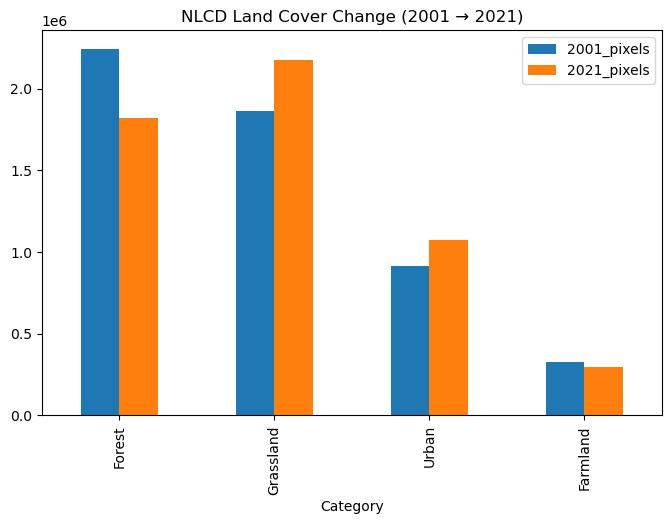

In [14]:
# Category → NLCD class codes
CATEGORIES = {
    "Forest": [41, 42, 43],
    "Grassland": [52, 71, 72],
    "Urban": [21, 22, 23, 24],
    "Farmland": [81, 82]
}

def summarize_categories(counts_dict):
    """Convert raw NLCD class histogram into grouped category totals."""
    summary = {}
    for cat, codes in CATEGORIES.items():
        summary[cat] = sum(counts_dict.get(str(code), 0) for code in codes)
    return summary

summary_2001 = summarize_categories(counts_2001)
summary_2021 = summarize_categories(counts_2021)

df = pd.DataFrame({
    "Category": list(CATEGORIES.keys()),
    "2001_pixels": [summary_2001[c] for c in CATEGORIES],
    "2021_pixels": [summary_2021[c] for c in CATEGORIES],
})

df["Change_pixels"] = df["2021_pixels"] - df["2001_pixels"]
df["Change_percent"] = 100 * df["Change_pixels"] / df["2001_pixels"]
df

df.set_index("Category")[["2001_pixels", "2021_pixels"]].plot.bar(
    figsize=(8,5), title="NLCD Land Cover Change (2001 → 2021)"
)

In [15]:
# Convert pixel counts to area in hectares
# NLCD pixel size = 30 m × 30 m = 900 m² = 0.09 ha

PIXEL_AREA_HA = 0.09

df["2001_area_ha"] = df["2001_pixels"] * PIXEL_AREA_HA
df["2021_area_ha"] = df["2021_pixels"] * PIXEL_AREA_HA
df["Change_area_ha"] = df["2021_area_ha"] - df["2001_area_ha"]

# Optional: convert hectares to square kilometers
df["2001_area_km2"] = df["2001_area_ha"] / 100
df["2021_area_km2"] = df["2021_area_ha"] / 100
df["Change_area_km2"] = df["Change_area_ha"] / 100

# Reorder columns for clearer display
area_change_df = df[
    [
        "Category",
        "2001_area_ha",
        "2021_area_ha",
        "Change_area_ha",
        "Change_percent",
        "2001_area_km2",
        "2021_area_km2",
        "Change_area_km2"
    ]
]

area_change_df.round(2)

,Category,2001_area_ha,2021_area_ha,Change_area_ha,Change_percent,2001_area_km2,2021_area_km2,Change_area_km2
0,Forest,202112.73,163616.25,-38496.47,-19.05,2021.13,1636.16,-384.96
1,Grassland,167748.69,195883.14,28134.45,16.77,1677.49,1958.83,281.34
2,Urban,82501.94,96460.48,13958.54,16.92,825.02,964.60,139.59
3,Farmland,29271.21,26440.47,-2830.74,-9.67,292.71,264.40,-28.31


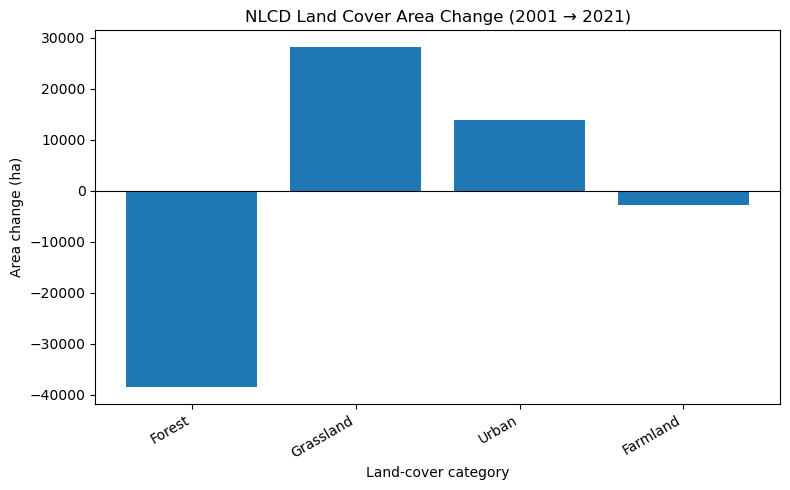

✅ Saved -> figures/nlcd_area_change_2001_2021.png


In [16]:
# Plot area change from 2001 to 2021

plt.figure(figsize=(8, 5))

plt.bar(
    area_change_df["Category"],
    area_change_df["Change_area_ha"]
)

plt.axhline(0, color="black", linewidth=0.8)

plt.xlabel("Land-cover category")
plt.ylabel("Area change (ha)")
plt.title("NLCD Land Cover Area Change (2001 → 2021)")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()

plt.savefig(
    "figures/nlcd_area_change_2001_2021.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("✅ Saved -> figures/nlcd_area_change_2001_2021.png")

In [17]:
########################  elevation  #############################

# Load and clip elevation data
dem = ee.Image('USGS/3DEP/10m').clip(study_area)

# Calculate elevation statistics
elev_stats = dem.reduceRegion(
    reducer=ee.Reducer.minMax(),
    geometry=study_area,
    scale=10,
    maxPixels=1e9,
    bestEffort=True
).getInfo()

elev_min = elev_stats['elevation_min']
elev_max = elev_stats['elevation_max']

print(f'Minimum elevation: {elev_min:.2f} m')
print(f'Maximum elevation: {elev_max:.2f} m')

Minimum elevation: 1479.70 m
Maximum elevation: 3281.42 m


In [59]:
# Visualization parameters based on actual elevation range
elev_vis = {
    'min': elev_min,
    'max': elev_max,
    'palette': [
        '#2b83ba',
        '#abdda4',
        '#ffffbf',
        '#fdae61',
        '#d7191c'
    ]
}

# Create map
Map6 = geemap.Map(
    center=[
        (lat_north + lat_south) / 2,
        (lon_west + lon_east) / 2
    ],
    zoom=9
)

Map6.addLayer(dem, elev_vis, 'Elevation (m)')
Map6.add_colorbar(elev_vis, label='Elevation (m)')

show_map(Map6)

Map(center=[40.125, -105.25833335], controls=(WidgetControl(options=['position', 'transparent_bg'], position='…

In [19]:
slope_stats = slope.reduceRegion(
    reducer=ee.Reducer.minMax(),
    geometry=study_area,
    scale=10,
    maxPixels=1e9,
    bestEffort=True
).getInfo()

print(slope_stats)

NameError: name 'slope' is not defined

In [22]:
slope = ee.Terrain.slope(dem)

slope_vis = {'min': 0, 'max': 30,
             'palette': ['#f7fcf5', '#74c476', '#238b45', '#00441b']}

Map7 = geemap.Map(center=[(lat_north + lat_south) / 2, (lon_west + lon_east) / 2], zoom=9)
Map7.addLayer(slope, slope_vis, 'Slope (degrees)')
Map7.add_colorbar(slope_vis, label='Slope (degrees)')
show_map(Map7)

Map(center=[40.125, -105.25833335], controls=(WidgetControl(options=['position', 'transparent_bg'], position='…

In [21]:
########################### Combine elevation and land-cover bands ###############################
# 1. Prepare elevation and NLCD images
# Rename the elevation band
elevation = dem.rename('elevation')

# Rename the NLCD land-cover band
landcover = nlcd_2021.rename('landcover')

# Combine elevation and land-cover into one image
# Band order:
#   0 = elevation
#   1 = landcover
combined = (
    elevation
    .addBands(landcover)
    .clip(study_area)
)

print('Combined image bands:')
print(combined.bandNames().getInfo())

# 2. Calculate mean elevation for each NLCD class
mean_result = combined.reduceRegion(
    reducer=ee.Reducer.mean().group(
        groupField=1,
        groupName='landcover'
    ),
    geometry=study_area,
    scale=30,
    maxPixels=1e13,
    bestEffort=True,
    tileScale=4
).getInfo()

print('\nMean elevation results:')
print(mean_result)

# 3. Calculate minimum elevation for each NLCD class
min_result = combined.reduceRegion(
    reducer=ee.Reducer.min().group(
        groupField=1,
        groupName='landcover'
    ),
    geometry=study_area,
    scale=30,
    maxPixels=1e13,
    bestEffort=True,
    tileScale=4
).getInfo()

print('\nMinimum elevation results:')
print(min_result)

# 4. Calculate maximum elevation for each NLCD class
max_result = combined.reduceRegion(
    reducer=ee.Reducer.max().group(
        groupField=1,
        groupName='landcover'
    ),
    geometry=study_area,
    scale=30,
    maxPixels=1e13,
    bestEffort=True,
    tileScale=4
).getInfo()

print('\nMaximum elevation results:')
print(max_result)



Combined image bands:
['elevation', 'landcover']

Mean elevation results:
{'groups': [{'landcover': 11, 'mean': 1634.7076227852938}, {'landcover': 21, 'mean': 1844.390536428174}, {'landcover': 22, 'mean': 1698.347770884379}, {'landcover': 23, 'mean': 1663.4653841447928}, {'landcover': 24, 'mean': 1650.4664954563411}, {'landcover': 31, 'mean': 1731.5412752062512}, {'landcover': 41, 'mean': 2411.651763485522}, {'landcover': 42, 'mean': 2356.574867840685}, {'landcover': 43, 'mean': 2420.929483717249}, {'landcover': 52, 'mean': 2039.9708802157684}, {'landcover': 71, 'mean': 1879.1055331845137}, {'landcover': 81, 'mean': 1581.3028935201892}, {'landcover': 82, 'mean': 1557.5414524310654}, {'landcover': 90, 'mean': 1939.1385526346262}, {'landcover': 95, 'mean': 1643.396593510138}]}

Minimum elevation results:
{'groups': [{'landcover': 11, 'min': 1479.699951171875}, {'landcover': 21, 'min': 1479.699951171875}, {'landcover': 22, 'min': 1479.699951171875}, {'landcover': 23, 'min': 1479.699951171

In [22]:
# 5. Convert Earth Engine results to Pandas DataFrames
mean_df = pd.DataFrame(mean_result.get('groups', []))
min_df = pd.DataFrame(min_result.get('groups', []))
max_df = pd.DataFrame(max_result.get('groups', []))

# Rename columns
mean_df = mean_df.rename(
    columns={
        'landcover': 'NLCD_class',
        'mean': 'mean_elevation_m'
    }
)

min_df = min_df.rename(
    columns={
        'landcover': 'NLCD_class',
        'min': 'min_elevation_m'
    }
)

max_df = max_df.rename(
    columns={
        'landcover': 'NLCD_class',
        'max': 'max_elevation_m'
    }
)

# 6. Merge mean, minimum, and maximum elevation results
elevation_by_landcover = (
    mean_df
    .merge(min_df, on='NLCD_class', how='outer')
    .merge(max_df, on='NLCD_class', how='outer')
)


In [23]:
# Define colors for NLCD classes
nlcd_color_map = {
    'Water': '#47b7eb',
    'Perennial Ice/Snow': '#a5edf5',

    'Dev-Open': '#eda1a1',
    'Dev-Low': '#e87f7f',
    'Dev-Med': '#ed0000',
    'Dev-High': '#ab0000',

    'Barren Land': '#d4c798',

    'Deciduous Forest': '#68ab63',
    'Evergreen Forest': '#1c6330',
    'Mixed Forest': '#a0d18d',

    'Shrub/Scrub': '#ccb879',

    'Grassland': '#e3d28e',

    'Pasture/Hay': '#dbd93d',
    'Cultivated Crops': '#ab7028',

    'Woody Wetlands': '#9eaf9e',
    'Emergent Herbaceous Wetlands': '#c6d18c'
}

In [24]:
# 7. Add NLCD class names
nlcd_class_names = {
    11: 'Open Water',
    12: 'Perennial Ice/Snow',
    21: 'Developed, Open Space',
    22: 'Developed, Low Intensity',
    23: 'Developed, Medium Intensity',
    24: 'Developed, High Intensity',
    31: 'Barren Land',
    41: 'Deciduous Forest',
    42: 'Evergreen Forest',
    43: 'Mixed Forest',
    51: 'Dwarf Scrub',
    52: 'Shrub/Scrub',
    71: 'Grassland/Herbaceous',
    72: 'Sedge/Herbaceous',
    73: 'Lichens',
    74: 'Moss',
    81: 'Pasture/Hay',
    82: 'Cultivated Crops',
    90: 'Woody Wetlands',
    95: 'Emergent Herbaceous Wetlands'
}

# Make sure the class codes are integers
elevation_by_landcover['NLCD_class'] = (
    elevation_by_landcover['NLCD_class'].astype(int)
)

# Add class descriptions
elevation_by_landcover['NLCD_name'] = (
    elevation_by_landcover['NLCD_class']
    .map(nlcd_class_names)
    .fillna('Other / Unknown')
)

# 8. Reorder and sort the final table
elevation_by_landcover = elevation_by_landcover[
    [
        'NLCD_class',
        'NLCD_name',
        'mean_elevation_m',
        'min_elevation_m',
        'max_elevation_m'
    ]
]

elevation_by_landcover = (
    elevation_by_landcover
    .sort_values('NLCD_class')
    .reset_index(drop=True)
)

# Round elevation values to two decimal places
elevation_by_landcover[
    [
        'mean_elevation_m',
        'min_elevation_m',
        'max_elevation_m'
    ]
] = elevation_by_landcover[
    [
        'mean_elevation_m',
        'min_elevation_m',
        'max_elevation_m'
    ]
].round(2)

# 9. Display final results
print('\nElevation statistics by NLCD land-cover class:')
display(elevation_by_landcover)


Elevation statistics by NLCD land-cover class:


,NLCD_class,NLCD_name,mean_elevation_m,min_elevation_m,max_elevation_m
0,11,Open Water,1634.71,1479.70,2746.61
1,21,"Developed, Open Space",1844.39,1479.70,3036.03
2,22,"Developed, Low Intensity",1698.35,1479.70,3022.20
3,23,"Developed, Medium Intensity",1663.47,1479.70,3028.79
4,24,"Developed, High Intensity",1650.47,1495.21,3000.99
5,31,Barren Land,1731.54,1489.33,3182.03
6,41,Deciduous Forest,2411.65,1491.97,3264.69
7,42,Evergreen Forest,2356.57,1497.89,3275.80
8,43,Mixed Forest,2420.93,1495.51,3269.39
9,52,Shrub/Scrub,2039.97,1492.16,3235.32


In [25]:
# ============================================================
# 1. Settings
# ============================================================

# Width of each elevation interval, in meters
bin_size = 100

# Analysis scale
analysis_scale = 30

# Land-cover category order
category_order = [
    'Forest',
    'Grassland',
    'Urban',
    'Farmland'
]

# Category IDs used internally
category_id_to_name = {
    1: 'Forest',
    2: 'Grassland',
    3: 'Urban',
    4: 'Farmland'
}

In [26]:
# ============================================================
# 2. Prepare elevation image
# ============================================================

# Make sure the DEM has only one band with a clear name
elevation = (
    dem
    .select([0])
    .rename('elevation')
    .clip(study_area)
)

# Convert continuous elevation into elevation bins
#
# For example, when bin_size = 100:
# 1500–1599 m becomes bin index 15
# 1600–1699 m becomes bin index 16
elevation_bin_index = (
    elevation
    .divide(bin_size)
    .floor()
    .toInt()
    .rename('elevation_bin_index')
)

# Pixel area in hectares
pixel_area_ha = (
    ee.Image.pixelArea()
    .divide(10000)
    .rename('area_ha')
)


In [27]:
# ============================================================
# 3. Function to reclassify NLCD
# ============================================================

def reclassify_nlcd(nlcd_image):
    """
    Reclassify NLCD codes into four broad categories:

    1 = Forest:    41, 42, 43
    2 = Grassland: 52, 71, 72
    3 = Urban:     21, 22, 23, 24
    4 = Farmland:  81, 82

    All other NLCD classes are masked out.
    """

    nlcd = (
        nlcd_image
        .select([0])
        .rename('nlcd')
        .toInt()
    )

    # Reclassify the selected NLCD codes
    reclassified = nlcd.remap(
        from_=[
            41, 42, 43,          # Forest
            52, 71, 72,          # Grassland
            21, 22, 23, 24,      # Urban
            81, 82                # Farmland
        ],
        to=[
            1, 1, 1,             # Forest
            2, 2, 2,             # Grassland
            3, 3, 3, 3,          # Urban
            4, 4                  # Farmland
        ],
        defaultValue=0
    ).rename('category_id')

    # Remove all classes not included in the four target categories
    reclassified = reclassified.updateMask(
        reclassified.gt(0)
    )

    return reclassified

In [28]:
# ============================================================
# 4. Function to calculate area by elevation and category
# ============================================================

def calculate_area_by_elevation(nlcd_image, year):
    """
    Calculate the area of each land-cover category within each
    elevation interval using all valid pixels.

    Returns
    -------
    pandas.DataFrame
        Columns:
        year
        elevation_bin
        landcover_category
        area_ha
        area_km2
    """

    # Reclassify NLCD into the four categories
    landcover_category = reclassify_nlcd(nlcd_image)

    # Keep pixels with valid elevation and valid land-cover category
    valid_mask = (
        elevation.mask()
        .And(landcover_category.mask())
    )

    # Create a combined grouping ID
    #
    # Example:
    # elevation bin index = 15
    # category ID = 2
    # group ID = 15 * 10 + 2 = 152
    #
    # This allows elevation and land cover to be grouped together
    # without random sampling.
    group_id = (
        elevation_bin_index
        .multiply(10)
        .add(landcover_category)
        .toInt()
        .rename('group_id')
    )

    # Band order:
    # 0 = area_ha
    # 1 = group_id
    analysis_image = (
        pixel_area_ha
        .addBands(group_id)
        .updateMask(valid_mask)
        .clip(study_area)
    )

    print(f'\nBands used for {year}:')
    print(analysis_image.bandNames().getInfo())

    # Sum pixel area for every unique group ID
    grouped_result = analysis_image.reduceRegion(
        reducer=ee.Reducer.sum().group(
            groupField=1,
            groupName='group_id'
        ),
        geometry=study_area,
        scale=analysis_scale,
        maxPixels=1e13,
        tileScale=4
    ).getInfo()

    records = []

    for item in grouped_result.get('groups', []):

        group_value = int(item['group_id'])

        # Recover category ID from the last digit
        category_id = group_value % 10

        # Recover elevation-bin index
        elevation_index = group_value // 10

        # Convert the bin index back to elevation in meters
        elevation_bin = elevation_index * bin_size

        # Ignore unexpected category IDs
        if category_id not in category_id_to_name:
            continue

        area_ha = float(item['sum'])

        records.append({
            'year': int(year),
            'elevation_bin': int(elevation_bin),
            'landcover_category': category_id_to_name[category_id],
            'area_ha': area_ha,
            'area_km2': area_ha / 100
        })

    result_df = pd.DataFrame(records)

    if result_df.empty:
        print(f'Warning: no valid data were returned for {year}.')
        return result_df

    result_df = (
        result_df
        .sort_values(
            ['elevation_bin', 'landcover_category']
        )
        .reset_index(drop=True)
    )

    return result_df

In [29]:
# ============================================================
# 5. Calculate area distributions for 2001 and 2021
# ============================================================

area_2001 = calculate_area_by_elevation(
    nlcd_image=nlcd_2001,
    year=2001
)

area_2021 = calculate_area_by_elevation(
    nlcd_image=nlcd_2021,
    year=2021
)

# Combine the two years
area_summary = pd.concat(
    [area_2001, area_2021],
    ignore_index=True
)

print('\nArea summary:')
display(area_summary.head(20))



Bands used for 2001:
['area_ha', 'group_id']

Bands used for 2021:
['area_ha', 'group_id']

Area summary:


,year,elevation_bin,landcover_category,area_ha,area_km2
0,2001,1400,Farmland,333.500215,3.335002
1,2001,1400,Forest,3.773223,0.037732
2,2001,1400,Grassland,119.882942,1.198829
3,2001,1400,Urban,129.405924,1.294059
4,2001,1500,Farmland,24399.467644,243.994676
5,2001,1500,Forest,273.732293,2.737323
6,2001,1500,Grassland,25205.146782,252.051468
7,2001,1500,Urban,26054.205418,260.542054
8,2001,1600,Farmland,4361.002172,43.610022
9,2001,1600,Forest,573.376188,5.733762


In [30]:
# ============================================================
# 6. Create complete elevation-category combinations
# ============================================================

# Find the full elevation range across both years
minimum_elevation = int(
    area_summary['elevation_bin'].min()
)

maximum_elevation = int(
    area_summary['elevation_bin'].max()
)

all_elevation_bins = list(
    range(
        minimum_elevation,
        maximum_elevation + bin_size,
        bin_size
    )
)

# Create all combinations of:
# year × elevation bin × land-cover category
complete_index = pd.MultiIndex.from_product(
    [
        [2001, 2021],
        all_elevation_bins,
        category_order
    ],
    names=[
        'year',
        'elevation_bin',
        'landcover_category'
    ]
)

area_complete = (
    area_summary
    .set_index(
        [
            'year',
            'elevation_bin',
            'landcover_category'
        ]
    )
    .reindex(complete_index)
    .reset_index()
)

# Missing combinations mean zero area
area_complete['area_ha'] = (
    area_complete['area_ha']
    .fillna(0)
)

area_complete['area_km2'] = (
    area_complete['area_km2']
    .fillna(0)
)

# Use the midpoint of each elevation interval for plotting
area_complete['elevation_midpoint'] = (
    area_complete['elevation_bin']
    + bin_size / 2
)

print('\nCompleted area table:')
display(area_complete.head(20))


Completed area table:


,year,elevation_bin,landcover_category,area_ha,area_km2,elevation_midpoint
0,2001,1400,Forest,3.773223,0.037732,1450.0
1,2001,1400,Grassland,119.882942,1.198829,1450.0
2,2001,1400,Urban,129.405924,1.294059,1450.0
3,2001,1400,Farmland,333.500215,3.335002,1450.0
4,2001,1500,Forest,273.732293,2.737323,1550.0
5,2001,1500,Grassland,25205.146782,252.051468,1550.0
6,2001,1500,Urban,26054.205418,260.542054,1550.0
7,2001,1500,Farmland,24399.467644,243.994676,1550.0
8,2001,1600,Forest,573.376188,5.733762,1650.0
9,2001,1600,Grassland,32960.868626,329.608686,1650.0


In [31]:
# ============================================================
# 7. Prepare pivot tables for plotting
# ============================================================

plot_tables = {}

for year in [2001, 2021]:

    year_data = area_complete[
        area_complete['year'] == year
    ].copy()

    pivot_table = year_data.pivot_table(
        index='elevation_midpoint',
        columns='landcover_category',
        values='area_km2',
        aggfunc='sum',
        fill_value=0
    )

    # Use the same category order in both panels
    pivot_table = pivot_table.reindex(
        columns=category_order,
        fill_value=0
    )

    pivot_table = pivot_table.sort_index()

    plot_tables[year] = pivot_table

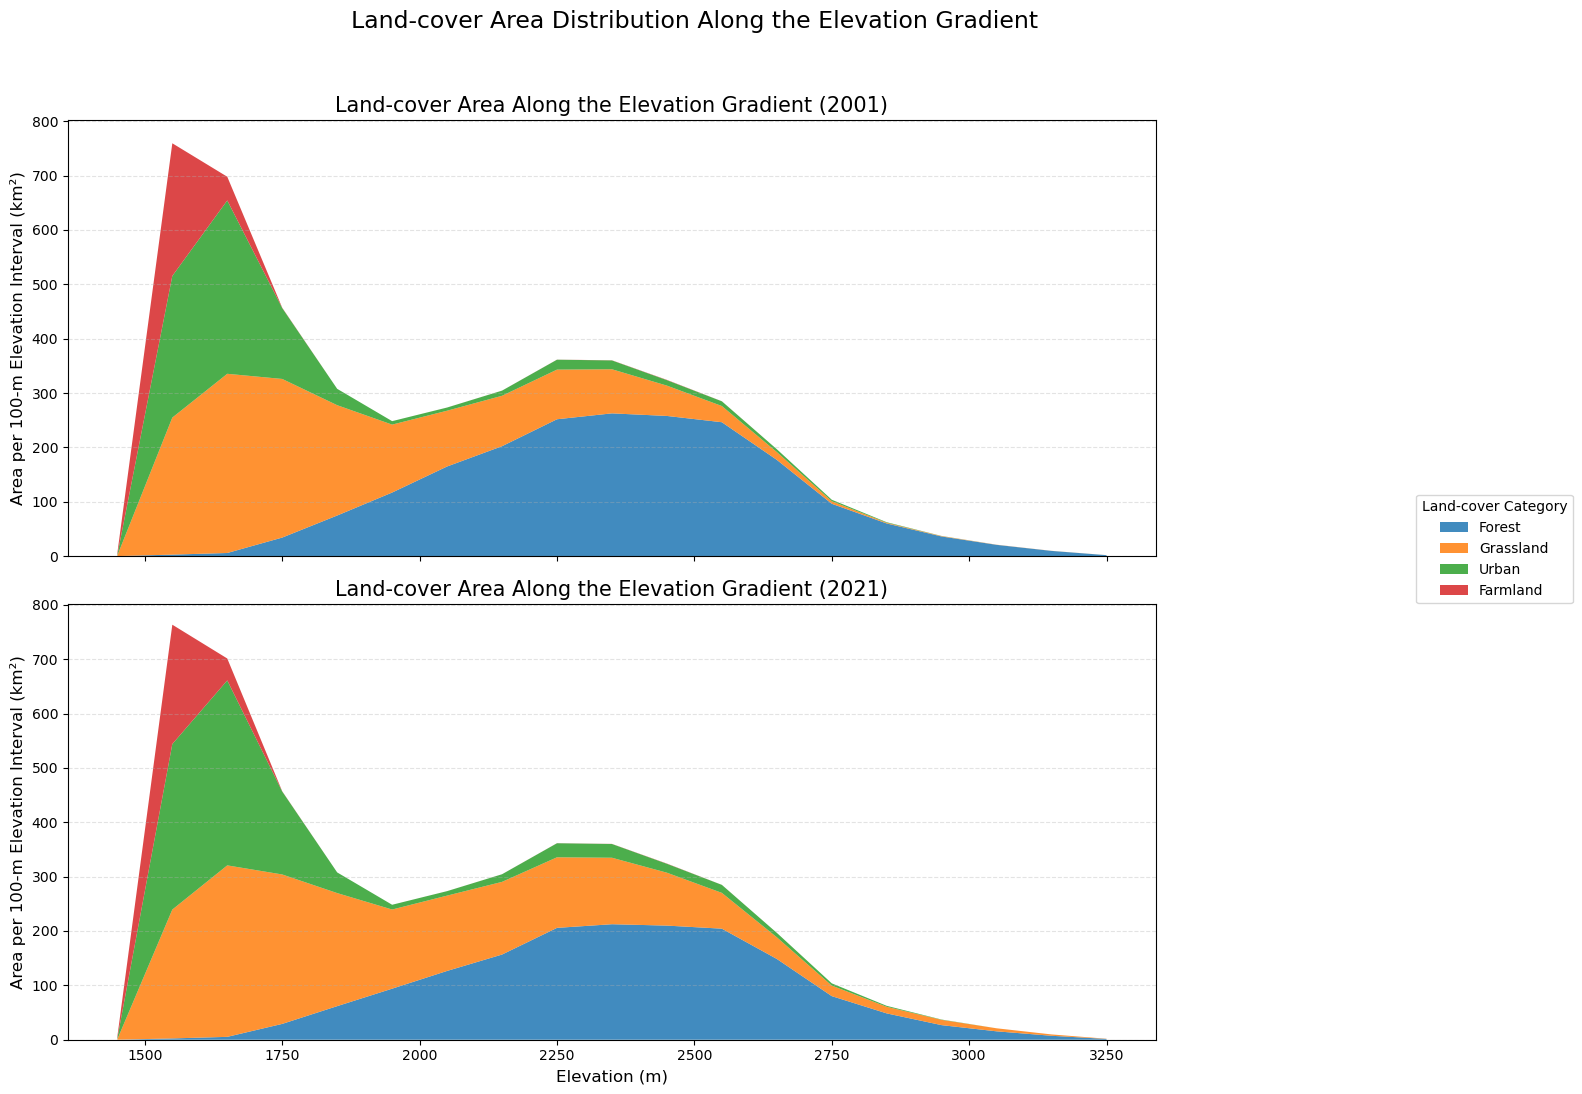

In [32]:
# ============================================================
# 8. Draw stacked area plots
# ============================================================

fig, axes = plt.subplots(
    nrows=2,
    ncols=1,
    figsize=(14, 11),
    sharex=True,
    sharey=True
)

for ax, year in zip(axes, [2001, 2021]):

    plot_df = plot_tables[year]

    ax.stackplot(
        plot_df.index,
        [
            plot_df['Forest'].values,
            plot_df['Grassland'].values,
            plot_df['Urban'].values,
            plot_df['Farmland'].values
        ],
        labels=category_order,
        alpha=0.85
    )

    ax.set_title(
        f'Land-cover Area Along the Elevation Gradient ({year})',
        fontsize=15
    )

    ax.set_ylabel(
        f'Area per {bin_size}-m Elevation Interval (km²)',
        fontsize=12
    )

    ax.grid(
        axis='y',
        linestyle='--',
        alpha=0.35
    )

# Shared x-axis label
axes[-1].set_xlabel(
    'Elevation (m)',
    fontsize=12
)

# Use one shared legend
handles, labels = axes[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    title='Land-cover Category',
    loc='center left',
    bbox_to_anchor=(1.01, 0.5)
)

fig.suptitle(
    'Land-cover Area Distribution Along the Elevation Gradient',
    fontsize=17,
    y=0.99
)

plt.tight_layout(
    rect=[0, 0, 0.84, 0.96]
)


# ============================================================
# 9. Save and display the figure
# ============================================================

plt.savefig(
    'landcover_area_along_elevation_gradient.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

In [33]:
# ============================================================
# Figure 2:
# Elevation distribution of each land-cover category
# Comparison between 2001 and 2021
# ============================================================

# ============================================================
# 1. Basic settings
# ============================================================

# Width of each elevation interval, in meters
bin_size = 100

# Spatial resolution used for the analysis
analysis_scale = 30

# Land-cover categories used in the analysis
category_order = [
    'Forest',
    'Grassland',
    'Urban',
    'Farmland'
]

# Internal category IDs
category_id_to_name = {
    1: 'Forest',
    2: 'Grassland',
    3: 'Urban',
    4: 'Farmland'
}


In [34]:
# ============================================================
# 2. Prepare elevation data
# ============================================================

# Select the first DEM band and rename it
elevation = (
    dem
    .select([0])
    .rename('elevation')
    .clip(study_area)
)

# Divide continuous elevation into intervals
#
# Example when bin_size = 100:
# 1500–1599 m -> bin index 15
# 1600–1699 m -> bin index 16
elevation_bin_index = (
    elevation
    .divide(bin_size)
    .floor()
    .toInt()
    .rename('elevation_bin_index')
)

# Pixel area in hectares
pixel_area_ha = (
    ee.Image.pixelArea()
    .divide(10000)
    .rename('area_ha')
)

In [35]:
# ============================================================
# 3. Reclassify NLCD into four categories
# ============================================================

def reclassify_nlcd(nlcd_image):
    """
    Reclassify NLCD codes into four broad categories.

    Forest:
        41 Deciduous Forest
        42 Evergreen Forest
        43 Mixed Forest

    Grassland:
        52 Shrub/Scrub
        71 Grassland/Herbaceous
        72 Sedge/Herbaceous

    Urban:
        21 Developed, Open Space
        22 Developed, Low Intensity
        23 Developed, Medium Intensity
        24 Developed, High Intensity

    Farmland:
        81 Pasture/Hay
        82 Cultivated Crops
    """

    nlcd = (
        nlcd_image
        .select([0])
        .rename('nlcd')
        .toInt()
    )

    reclassified = nlcd.remap(
        from_=[
            41, 42, 43,
            52, 71, 72,
            21, 22, 23, 24,
            81, 82
        ],
        to=[
            1, 1, 1,
            2, 2, 2,
            3, 3, 3, 3,
            4, 4
        ],
        defaultValue=0
    ).rename('category_id')

    # Exclude all NLCD classes outside the four target categories
    reclassified = reclassified.updateMask(
        reclassified.gt(0)
    )

    return reclassified


In [36]:
# ============================================================
# 4. Calculate land-cover area by elevation interval
# ============================================================

def calculate_area_by_elevation(nlcd_image, year):
    """
    Calculate the area of each land-cover category within
    each elevation interval.

    This function uses all valid pixels in the study area.
    """

    landcover_category = reclassify_nlcd(nlcd_image)

    # Retain pixels that have both valid elevation and land cover
    valid_mask = (
        elevation.mask()
        .And(landcover_category.mask())
    )

    # Create a unique ID for each combination of:
    # elevation interval + land-cover category
    #
    # Example:
    # elevation bin index = 15
    # category ID = 2
    # group ID = 15 × 10 + 2 = 152
    group_id = (
        elevation_bin_index
        .multiply(10)
        .add(landcover_category)
        .toInt()
        .rename('group_id')
    )

    # Band order:
    # band 0 = area_ha
    # band 1 = group_id
    analysis_image = (
        pixel_area_ha
        .addBands(group_id)
        .updateMask(valid_mask)
        .clip(study_area)
    )

    print(f'\nProcessing {year}...')
    print('Bands:', analysis_image.bandNames().getInfo())

    grouped_result = analysis_image.reduceRegion(
        reducer=ee.Reducer.sum().group(
            groupField=1,
            groupName='group_id'
        ),
        geometry=study_area,
        scale=analysis_scale,
        maxPixels=1e13,
        tileScale=4
    ).getInfo()

    records = []

    for item in grouped_result.get('groups', []):

        group_value = int(item['group_id'])

        # Recover the land-cover category ID
        category_id = group_value % 10

        # Recover the elevation-bin index
        elevation_index = group_value // 10

        # Convert bin index back to elevation in meters
        elevation_bin = elevation_index * bin_size

        if category_id not in category_id_to_name:
            continue

        area_ha = float(item['sum'])

        records.append({
            'year': int(year),
            'elevation_bin': int(elevation_bin),
            'landcover_category':
                category_id_to_name[category_id],
            'area_ha': area_ha,
            'area_km2': area_ha / 100
        })

    result_df = pd.DataFrame(records)

    if result_df.empty:
        print(f'Warning: no valid data returned for {year}.')
        return result_df

    result_df = (
        result_df
        .sort_values(
            ['landcover_category', 'elevation_bin']
        )
        .reset_index(drop=True)
    )

    return result_df

In [37]:
# ============================================================
# 5. Calculate results for 2001 and 2021
# ============================================================

area_2001 = calculate_area_by_elevation(
    nlcd_image=nlcd_2001,
    year=2001
)

area_2021 = calculate_area_by_elevation(
    nlcd_image=nlcd_2021,
    year=2021
)

# Combine the two years
area_summary = pd.concat(
    [area_2001, area_2021],
    ignore_index=True
)

print('\nArea by elevation interval:')
display(area_summary.head(20))



Processing 2001...
Bands: ['area_ha', 'group_id']

Processing 2021...
Bands: ['area_ha', 'group_id']

Area by elevation interval:


,year,elevation_bin,landcover_category,area_ha,area_km2
0,2001,1400,Farmland,333.500215,3.335002
1,2001,1500,Farmland,24399.467644,243.994676
2,2001,1600,Farmland,4361.002172,43.610022
3,2001,1700,Farmland,58.399218,0.583992
4,2001,1800,Farmland,0.551532,0.005515
5,2001,1900,Farmland,0.207466,0.002075
6,2001,2000,Farmland,5.391440,0.053914
7,2001,2100,Farmland,6.810609,0.068106
8,2001,2200,Farmland,13.669605,0.136696
9,2001,2300,Farmland,26.150631,0.261506


In [38]:
# ============================================================
# 6. Complete missing elevation-category combinations
# ============================================================

if area_summary.empty:
    raise ValueError(
        'No valid area results were returned. '
        'Check dem, nlcd_2001, nlcd_2021, and study_area.'
    )

minimum_elevation = int(
    area_summary['elevation_bin'].min()
)

maximum_elevation = int(
    area_summary['elevation_bin'].max()
)

all_elevation_bins = np.arange(
    minimum_elevation,
    maximum_elevation + bin_size,
    bin_size
)

# Create all possible combinations
complete_index = pd.MultiIndex.from_product(
    [
        [2001, 2021],
        category_order,
        all_elevation_bins
    ],
    names=[
        'year',
        'landcover_category',
        'elevation_bin'
    ]
)

area_complete = (
    area_summary
    .set_index(
        [
            'year',
            'landcover_category',
            'elevation_bin'
        ]
    )
    .reindex(complete_index)
    .reset_index()
)

# A missing combination means zero area
area_complete['area_ha'] = (
    area_complete['area_ha']
    .fillna(0)
)

area_complete['area_km2'] = (
    area_complete['area_km2']
    .fillna(0)
)

# Midpoint of each elevation interval
#
# Example:
# 1500–1600 m is plotted at 1550 m
area_complete['elevation_midpoint'] = (
    area_complete['elevation_bin']
    + bin_size / 2
)

In [39]:
# ============================================================
# 7. Calculate normalized elevation distributions
# ============================================================

# Total area of each category in each year
area_complete['total_category_area_km2'] = (
    area_complete
    .groupby(
        ['year', 'landcover_category']
    )['area_km2']
    .transform('sum')
)

# Percentage of a category's total area occurring
# in each elevation interval
area_complete['area_share_percent'] = np.where(
    area_complete['total_category_area_km2'] > 0,
    (
        area_complete['area_km2']
        / area_complete['total_category_area_km2']
        * 100
    ),
    0
)

print('\nNormalized elevation-distribution data:')
display(
    area_complete[
        [
            'year',
            'landcover_category',
            'elevation_bin',
            'elevation_midpoint',
            'area_km2',
            'total_category_area_km2',
            'area_share_percent'
        ]
    ].head(20)
)


Normalized elevation-distribution data:


,year,landcover_category,elevation_bin,elevation_midpoint,area_km2,total_category_area_km2,area_share_percent
0,2001,Forest,1400,1450.0,0.037732,2021.115923,0.001867
1,2001,Forest,1500,1550.0,2.737323,2021.115923,0.135436
2,2001,Forest,1600,1650.0,5.733762,2021.115923,0.283693
3,2001,Forest,1700,1750.0,34.109431,2021.115923,1.687653
4,2001,Forest,1800,1850.0,74.667385,2021.115923,3.694364
5,2001,Forest,1900,1950.0,116.938308,2021.115923,5.785829
6,2001,Forest,2000,2050.0,164.847656,2021.115923,8.156269
7,2001,Forest,2100,2150.0,202.162709,2021.115923,10.002529
8,2001,Forest,2200,2250.0,251.724715,2021.115923,12.454739
9,2001,Forest,2300,2350.0,262.559646,2021.115923,12.990826


In [40]:
# ============================================================
# 8. Optional smoothing
# ============================================================

# 1 means no smoothing
# 3 means a moving average across three elevation intervals
smooth_window = 3

area_complete = area_complete.sort_values(
    [
        'landcover_category',
        'year',
        'elevation_midpoint'
    ]
)

area_complete['area_share_smoothed'] = (
    area_complete
    .groupby(
        ['landcover_category', 'year']
    )['area_share_percent']
    .transform(
        lambda values: values.rolling(
            window=smooth_window,
            center=True,
            min_periods=1
        ).mean()
    )
)


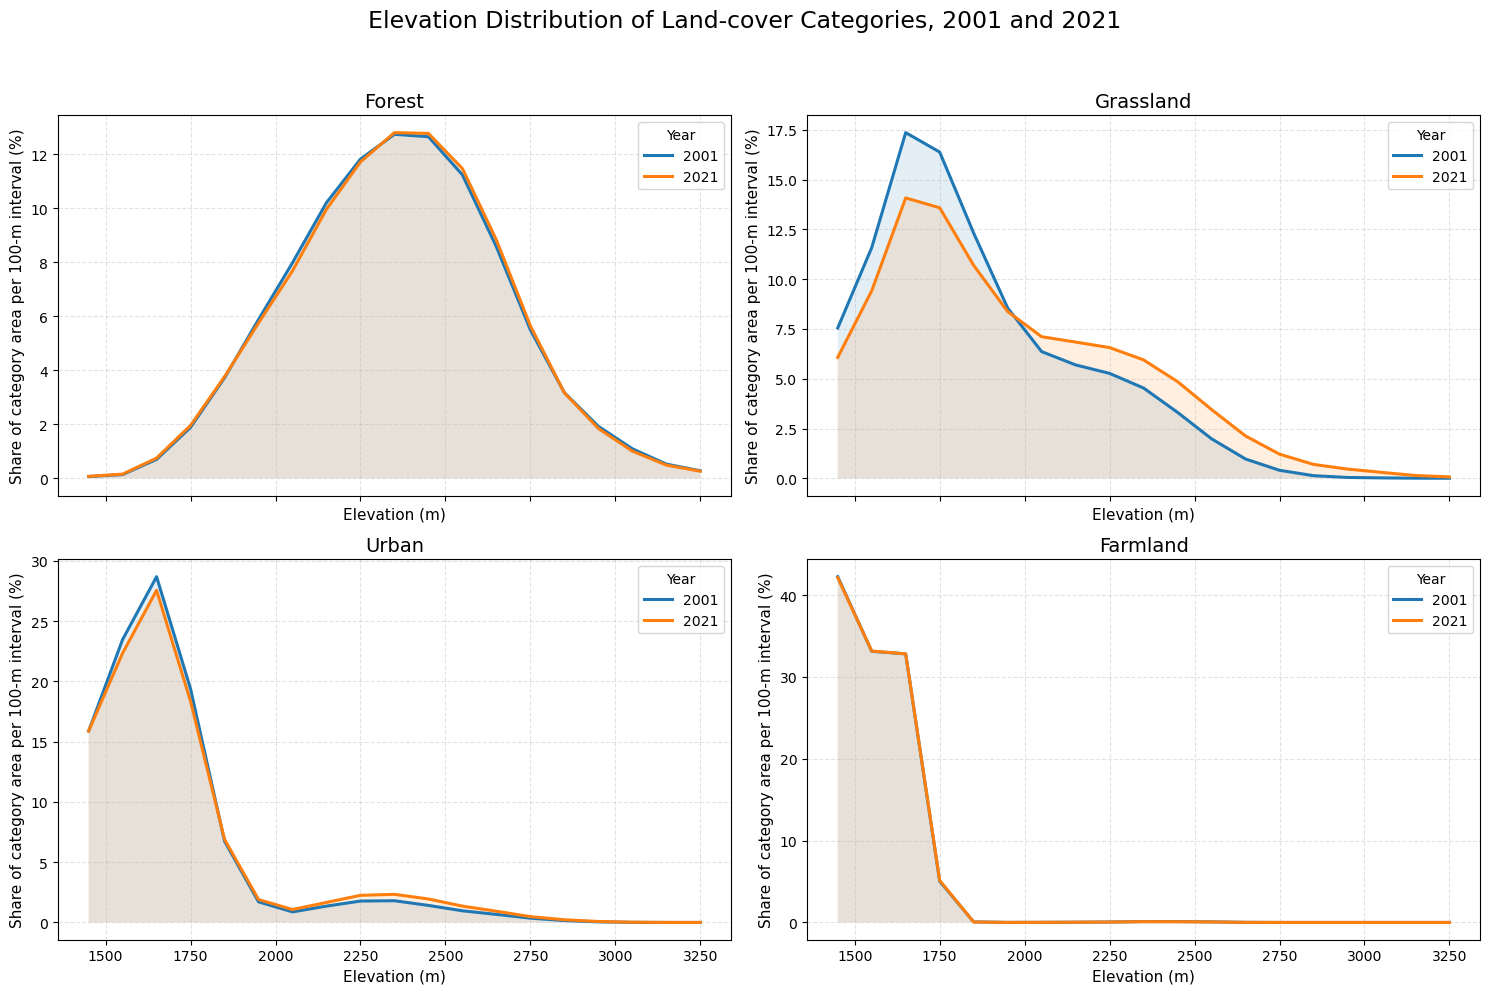

In [41]:
# ============================================================
# 9. Draw one panel for each land-cover category
# ============================================================

fig, axes = plt.subplots(
    nrows=2,
    ncols=2,
    figsize=(15, 10),
    sharex=True
)

axes = axes.flatten()

for ax, category in zip(axes, category_order):

    category_data = area_complete[
        area_complete['landcover_category'] == category
    ]

    for year in [2001, 2021]:

        year_data = category_data[
            category_data['year'] == year
        ].sort_values('elevation_midpoint')

        # Skip plotting if this category does not occur
        if year_data['area_km2'].sum() == 0:
            continue

        ax.plot(
            year_data['elevation_midpoint'],
            year_data['area_share_smoothed'],
            linewidth=2.2,
            label=str(year)
        )

        ax.fill_between(
            year_data['elevation_midpoint'],
            0,
            year_data['area_share_smoothed'],
            alpha=0.12
        )

    ax.set_title(
        category,
        fontsize=14
    )

    ax.set_xlabel(
        'Elevation (m)',
        fontsize=11
    )

    ax.set_ylabel(
        f'Share of category area per {bin_size}-m interval (%)',
        fontsize=11
    )

    ax.grid(
        linestyle='--',
        alpha=0.35
    )

    ax.legend(
        title='Year'
    )


fig.suptitle(
    'Elevation Distribution of Land-cover Categories, 2001 and 2021',
    fontsize=17,
    y=0.99
)

plt.tight_layout(
    rect=[0, 0, 1, 0.96]
)


In [42]:
# ============================================================
# 10. Save and display the figure
# ============================================================

plt.savefig(
    'landcover_elevation_distribution_2001_2021.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

<Figure size 640x480 with 0 Axes>

In [43]:
# ============================================================
# Figure 3:
# Elevation box plots by land-cover category
# Comparison between 2001 and 2021
# ============================================================

# ============================================================
# 1. Basic settings
# ============================================================

analysis_scale = 30 # 空间分辨率

category_order = [
    'Forest',
    'Grassland',
    'Urban',
    'Farmland'
]

category_name_to_id = {
    'Forest': 1,
    'Grassland': 2,
    'Urban': 3,
    'Farmland': 4
}

# ============================================================
# 2. Prepare elevation image
# ============================================================

elevation = (
    dem
    .select([0]) # 选择 dem 的第一个波段
    .rename('elevation')
    .clip(study_area)
)


In [44]:
# ============================================================
# 3. Reclassify NLCD into four categories
# ============================================================

def reclassify_nlcd(nlcd_image):
    """
    Reclassify NLCD into four broad categories.

    Forest:    41, 42, 43
    Grassland: 52, 71, 72
    Urban:     21, 22, 23, 24
    Farmland:  81, 82
    """

    nlcd = (
        nlcd_image
        .select([0]) # 选择输入影像的第一个波段
        .rename('nlcd')
        .toInt() # 把像元值转换为整数类型
    )

    reclassified = nlcd.remap(
        from_=[
            41, 42, 43,
            52, 71, 72,
            21, 22, 23, 24,
            81, 82
        ],
        to=[
            1, 1, 1,
            2, 2, 2,
            3, 3, 3, 3,
            4, 4
        ],
        defaultValue=0 # 如果某个原始 NLCD 类别没有出现在 from_ 列表中，就把它赋值为 0
    ).rename('category_id')

    return reclassified.updateMask(
        reclassified.gt(0) # 表示判断每个像元是否大于 0，大于 0 的像元保留
    )

In [45]:
# ============================================================
# 4. Calculate elevation statistics for one year
# ============================================================

def calculate_boxplot_statistics(nlcd_image, year):
    """
    Calculate elevation percentiles for each land-cover category.

    Percentiles:
    0   = minimum
    25  = first quartile
    50  = median
    75  = third quartile
    100 = maximum
    """

    landcover = reclassify_nlcd(nlcd_image) # 重新分类土地覆盖

    records = [] # 列表，保存每个类别的统计结果

    for category_name in category_order:

        category_id = category_name_to_id[category_name] # 根据名称找到类别编号

        # Mask elevation to the selected land-cover category
        category_elevation = elevation.updateMask( # 只保留当前类别的高程像元。比如森林，那么非森林像元就会被屏蔽
            landcover.eq(category_id)
        )

        # Calculate percentiles using all valid pixels  # 计算海拔百分位数
        stats = category_elevation.reduceRegion(
            reducer=ee.Reducer.percentile(
                [0, 25, 50, 75, 100]
            ),
            geometry=study_area,
            scale=analysis_scale,
            maxPixels=1e13,
            tileScale=4, # 允许处理非常多的像元，避免因为研究区太大而报错
            bestEffort=False # 把计算拆得更细一些，减少 Earth Engine 内存不足的风险。不要自动降低分辨率，尽量严格使用你设置的30米尺度
        ).getInfo() # 把 Earth Engine 服务器端的结果下载到本地 Python

        print(
            f'{year} - {category_name}:',
            stats
        )

        # Expected keys:
        # elevation_p0
        # elevation_p25
        # elevation_p50
        # elevation_p75
        # elevation_p100

        if not stats or stats.get('elevation_p50') is None: # 检查是否有有效像元
            print(
                f'Warning: no valid pixels for ' # 打印警告
                f'{category_name} in {year}.'
            )
            continue # 如果当前类别没有数据，就不会执行下面的 records.append()

        records.append({
            'year': int(year),
            'category': category_name,
            'min': float(stats['elevation_p0']),
            'q1': float(stats['elevation_p25']),
            'median': float(stats['elevation_p50']),
            'q3': float(stats['elevation_p75']),
            'max': float(stats['elevation_p100'])
        })

    return pd.DataFrame(records)


In [46]:
# ============================================================
# 5. Calculate statistics for 2001 and 2021
# ============================================================

box_2001 = calculate_boxplot_statistics(
    nlcd_image=nlcd_2001,
    year=2001
)

box_2021 = calculate_boxplot_statistics(
    nlcd_image=nlcd_2021,
    year=2021
)

box_stats = pd.concat( # 把两个 DataFrame 纵向拼接起来
    [box_2001, box_2021],
    ignore_index=True # ignore_index=True 的作用是重新生成连续索引
)

print('\nBox-plot statistics:') # \n 表示先换一行
display(box_stats)


2001 - Forest: {'elevation_p0': 1491.234619140625, 'elevation_p100': 3274.6280517578125, 'elevation_p25': 2155.999911622231, 'elevation_p50': 2355.9958794477857, 'elevation_p75': 2556.0099936332335}
2001 - Grassland: {'elevation_p0': 1479.699951171875, 'elevation_p100': 3269.3857421875, 'elevation_p25': 1651.8571693544416, 'elevation_p50': 1787.9803277488927, 'elevation_p75': 2051.98515793999}
2001 - Urban: {'elevation_p0': 1479.699951171875, 'elevation_p100': 3017.940673828125, 'elevation_p25': 1563.7200053977724, 'elevation_p50': 1652.0907778786898, 'elevation_p75': 1715.882466415338}
2001 - Farmland: {'elevation_p0': 1479.699951171875, 'elevation_p100': 2588.53564453125, 'elevation_p25': 1540.045737965088, 'elevation_p50': 1556.0605099246268, 'elevation_p75': 1579.653615605875}
2021 - Forest: {'elevation_p0': 1491.97021484375, 'elevation_p100': 3274.6280517578125, 'elevation_p25': 2156.004312756715, 'elevation_p50': 2364.025321865454, 'elevation_p75': 2556.0234907669665}
2021 - Gras

,year,category,min,q1,median,q3,max
0,2001,Forest,1491.234619,2155.999912,2355.995879,2556.009994,3274.628052
1,2001,Grassland,1479.699951,1651.857169,1787.980328,2051.985158,3269.385742
2,2001,Urban,1479.699951,1563.720005,1652.090778,1715.882466,3017.940674
3,2001,Farmland,1479.699951,1540.045738,1556.060510,1579.653616,2588.535645
4,2021,Forest,1491.970215,2156.004313,2364.025322,2556.023491,3274.628052
5,2021,Grassland,1487.590332,1683.962107,1867.971244,2211.985243,3266.171875
6,2021,Urban,1479.699951,1563.816493,1660.022116,1731.839202,3036.030762
7,2021,Farmland,1479.699951,1540.029154,1556.055128,1579.659534,2588.535645


In [47]:
# ============================================================
# 6. Prepare box-plot data for Matplotlib
# ============================================================

boxplot_data = []
boxplot_positions = []
boxplot_labels = []
boxplot_years = []

category_positions = {
    category: index + 1
    for index, category in enumerate(category_order)
}

offset = 0.25 # 设置年份之间的水平偏移

for category in category_order:

    base_position = category_positions[category]

    for year, position_offset in [
        (2001, -offset),
        (2021, offset)
    ]:

        row = box_stats[ # 从 box_stats 中筛选对应的一行
            (box_stats['category'] == category)
            & (box_stats['year'] == year)
        ]

        if row.empty: # 如果该年份某类别没有数据，就跳过，不创建箱线图
            continue

        row = row.iloc[0] # 筛选结果是一个 DataFrame，即使只有一行

        boxplot_data.append({
            'label': f'{category} {year}',
            'whislo': row['min'],
            'q1': row['q1'],
            'med': row['median'],
            'q3': row['q3'],
            'whishi': row['max'],
            'fliers': [] # 离群值列表
        })

        boxplot_positions.append(
            base_position + position_offset
        )

        boxplot_labels.append(category)
        boxplot_years.append(year)

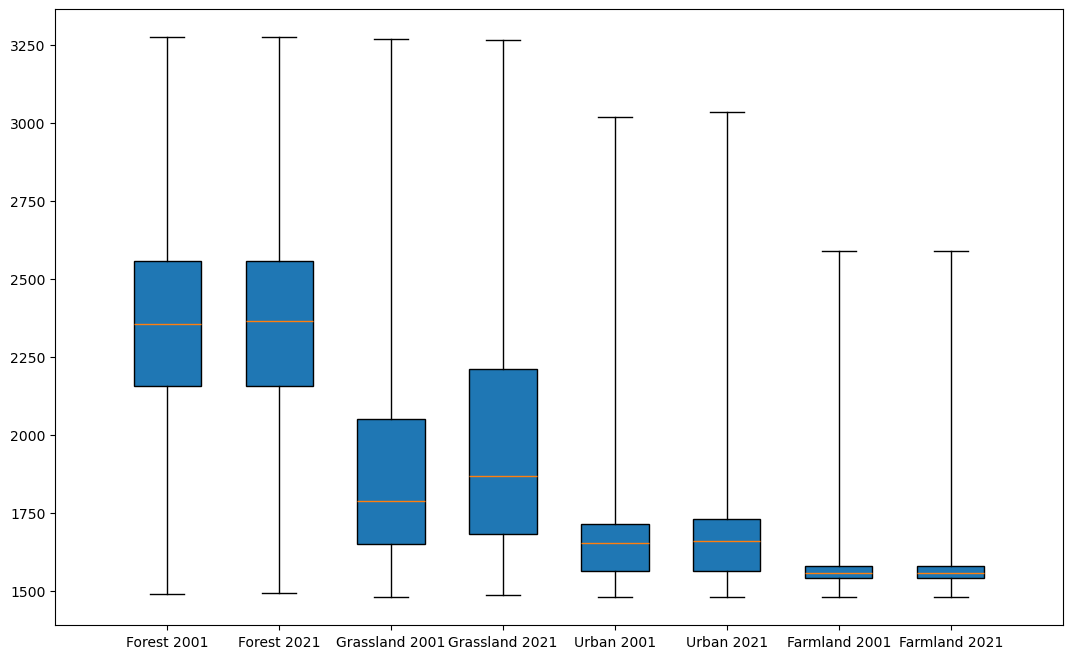

In [48]:
# ============================================================
# 7. Draw side-by-side box plots
# ============================================================

fig, ax = plt.subplots(
    figsize=(13, 8)
)

boxplot_artists = ax.bxp(
    boxplot_data, # 前面整理好的箱线图数据，包括最小值、Q1、中位数、Q3、最大值
    positions=boxplot_positions,
    widths=0.30,
    patch_artist=True, # 允许给箱体填充颜色。否则默认只有边框，不能方便地设置不同年份颜色
    showfliers=False # 不显示离群点
)

In [52]:
# ============================================================
# 8. Style boxes by year
# ============================================================

# Matplotlib default colors
year_colors = {
    2001: 'C0',
    2021: 'C1'
}

for box, year in zip(
    boxplot_artists['boxes'],
    boxplot_years
):
    box.set_facecolor(year_colors[year])
    box.set_alpha(0.55)
    box.set_edgecolor(year_colors[year])
    box.set_linewidth(1.5)

for median in boxplot_artists['medians']:
    median.set_color('black')
    median.set_linewidth(2)

# Color whiskers and caps according to their corresponding boxes
for index, year in enumerate(boxplot_years):

    whisker_1 = boxplot_artists['whiskers'][index * 2]
    whisker_2 = boxplot_artists['whiskers'][index * 2 + 1]

    cap_1 = boxplot_artists['caps'][index * 2]
    cap_2 = boxplot_artists['caps'][index * 2 + 1]

    for artist in [
        whisker_1,
        whisker_2,
        cap_1,
        cap_2
    ]:
        artist.set_color(year_colors[year])
        artist.set_linewidth(1.5)

In [53]:
# ============================================================
# 9. Axis labels and legend
# ============================================================

from matplotlib.patches import Patch

ax.set_xticks(
    list(category_positions.values())
)

ax.set_xticklabels(
    category_order,
    fontsize=12
)

ax.set_xlabel(
    'Land-cover Category',
    fontsize=13
)

ax.set_ylabel(
    'Elevation (m)',
    fontsize=13
)

ax.set_title(
    'Elevation Distribution by Land-cover Category, 2001 and 2021',
    fontsize=16
)

ax.grid(
    axis='y',
    linestyle='--',
    alpha=0.35
)

legend_handles = [
    Patch(
        facecolor=year_colors[2001],
        edgecolor=year_colors[2001],
        alpha=0.55,
        label='2001'
    ),
    Patch(
        facecolor=year_colors[2021],
        edgecolor=year_colors[2021],
        alpha=0.55,
        label='2021'
    )
]

ax.legend(
    handles=legend_handles,
    title='Year'
)

plt.tight_layout()


<Figure size 640x480 with 0 Axes>

In [54]:
# ============================================================
# 10. Save and display the figure
# ============================================================

plt.savefig(
    'landcover_elevation_boxplot_2001_2021.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

<Figure size 640x480 with 0 Axes>

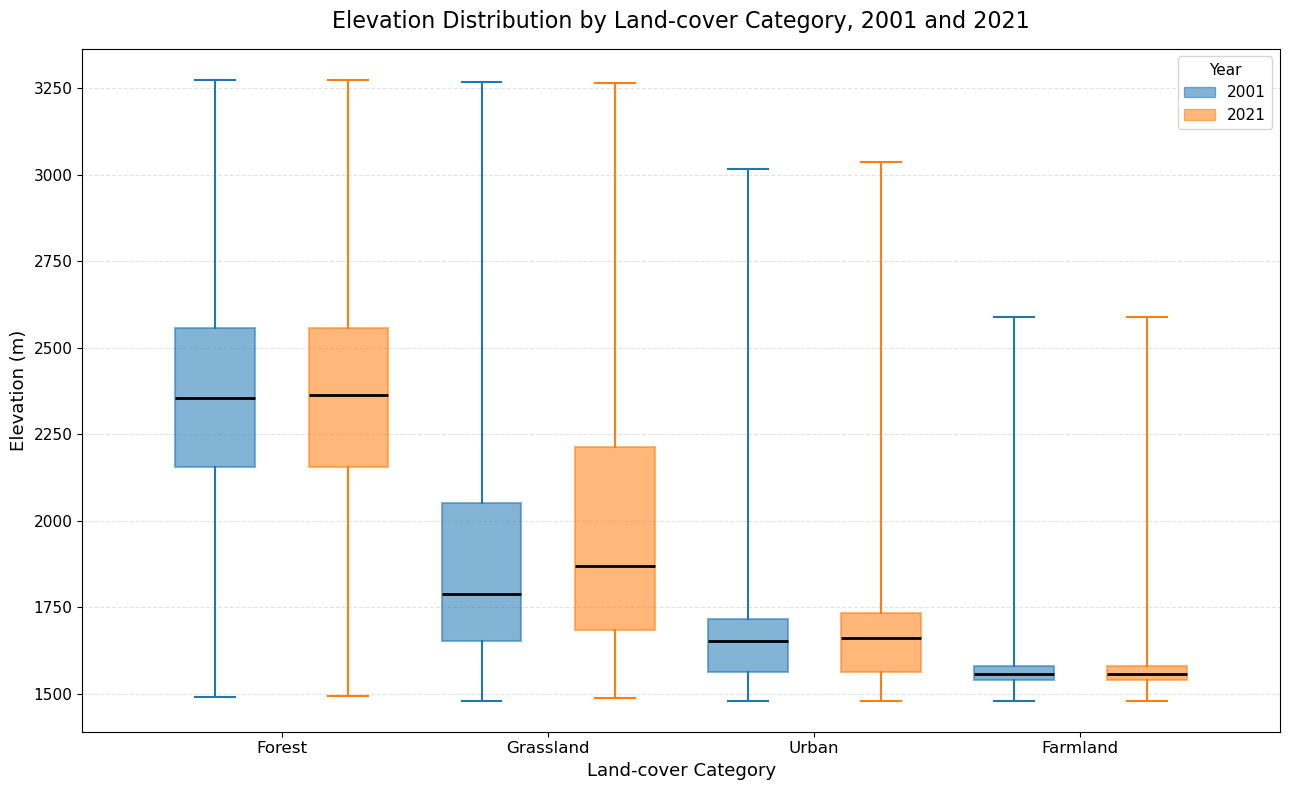

In [60]:
# ============================================================
# 7–10. Draw, style, label, save, and display the box plots
# ============================================================

import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# ------------------------------------------------------------
# 1. Create the figure
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(13, 8))

boxplot_artists = ax.bxp(
    boxplot_data,
    positions=boxplot_positions,
    widths=0.30,
    patch_artist=True,
    showfliers=False
)

# ------------------------------------------------------------
# 2. Style boxes by year
# ------------------------------------------------------------

year_colors = {
    2001: 'C0',
    2021: 'C1'
}

# Set box colors
for box, year in zip(
    boxplot_artists['boxes'],
    boxplot_years
):
    box.set_facecolor(year_colors[year])
    box.set_alpha(0.55)
    box.set_edgecolor(year_colors[year])
    box.set_linewidth(1.5)

# Set median-line style
for median in boxplot_artists['medians']:
    median.set_color('black')
    median.set_linewidth(2)

# Set whisker and cap colors
for index, year in enumerate(boxplot_years):

    whisker_1 = boxplot_artists['whiskers'][index * 2]
    whisker_2 = boxplot_artists['whiskers'][index * 2 + 1]

    cap_1 = boxplot_artists['caps'][index * 2]
    cap_2 = boxplot_artists['caps'][index * 2 + 1]

    for artist in [
        whisker_1,
        whisker_2,
        cap_1,
        cap_2
    ]:
        artist.set_color(year_colors[year])
        artist.set_linewidth(1.5)

# ------------------------------------------------------------
# 3. Set axis labels and title
# ------------------------------------------------------------

ax.set_xticks(
    list(category_positions.values())
)

ax.set_xticklabels(
    category_order,
    fontsize=12
)

ax.set_xlabel(
    'Land-cover Category',
    fontsize=13
)

ax.set_ylabel(
    'Elevation (m)',
    fontsize=13
)

ax.set_title(
    'Elevation Distribution by Land-cover Category, 2001 and 2021',
    fontsize=16,
    pad=15
)

ax.tick_params(
    axis='y',
    labelsize=11
)

ax.grid(
    axis='y',
    linestyle='--',
    alpha=0.35
)

# ------------------------------------------------------------
# 4. Add legend
# ------------------------------------------------------------

legend_handles = [
    Patch(
        facecolor=year_colors[2001],
        edgecolor=year_colors[2001],
        alpha=0.55,
        label='2001'
    ),
    Patch(
        facecolor=year_colors[2021],
        edgecolor=year_colors[2021],
        alpha=0.55,
        label='2021'
    )
]

ax.legend(
    handles=legend_handles,
    title='Year',
    fontsize=11,
    title_fontsize=11
)

# ------------------------------------------------------------
# 5. Adjust layout, save, and display
# ------------------------------------------------------------

fig.tight_layout()

fig.savefig(
    'landcover_elevation_boxplot_2001_2021.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

In [61]:
# ============================================================
# Prepare slope image
# ============================================================

slope = (
    ee.Terrain.slope(
        dem.select([0])
    )
    .rename('slope')
    .clip(study_area)
)

print('Slope image prepared.')

Slope image prepared.


In [62]:
# ============================================================
# Calculate slope statistics for one year
# ============================================================

def calculate_slope_boxplot_statistics(nlcd_image, year):
    """
    Calculate slope percentiles for each land-cover category.

    Percentiles:
    0   = minimum
    25  = first quartile
    50  = median
    75  = third quartile
    100 = maximum
    """

    landcover = reclassify_nlcd(nlcd_image)

    records = []

    for category_name in category_order:

        category_id = category_name_to_id[category_name]

        # Only retain slope pixels belonging to this land-cover category
        category_slope = slope.updateMask(
            landcover.eq(category_id)
        )

        stats = category_slope.reduceRegion(
            reducer=ee.Reducer.percentile(
                [0, 25, 50, 75, 100]
            ),
            geometry=study_area,
            scale=analysis_scale,
            maxPixels=1e13,
            tileScale=4,
            bestEffort=False
        ).getInfo()

        print(
            f'{year} - {category_name}:',
            stats
        )

        # Check whether valid pixels exist
        if not stats or stats.get('slope_p50') is None:
            print(
                f'Warning: no valid slope pixels for '
                f'{category_name} in {year}.'
            )
            continue

        records.append({
            'year': int(year),
            'category': category_name,
            'min': float(stats['slope_p0']),
            'q1': float(stats['slope_p25']),
            'median': float(stats['slope_p50']),
            'q3': float(stats['slope_p75']),
            'max': float(stats['slope_p100'])
        })

    return pd.DataFrame(records)

In [63]:
# ============================================================
# Calculate statistics for 2001 and 2021
# ============================================================

slope_box_2001 = calculate_slope_boxplot_statistics(
    nlcd_image=nlcd_2001,
    year=2001
)

slope_box_2021 = calculate_slope_boxplot_statistics(
    nlcd_image=nlcd_2021,
    year=2021
)

slope_box_stats = pd.concat(
    [slope_box_2001, slope_box_2021],
    ignore_index=True
)

print('\nSlope box-plot statistics:')
display(slope_box_stats)

2001 - Forest: {'slope_p0': 0, 'slope_p100': 74.3553485552747, 'slope_p25': 11.750955063574333, 'slope_p50': 17.750043425408617, 'slope_p75': 24.748917375332393}
2001 - Grassland: {'slope_p0': 0, 'slope_p100': 76.37998342809371, 'slope_p25': 3.2451596638751368, 'slope_p50': 8.748629990844483, 'slope_p75': 18.25011647159388}
2001 - Urban: {'slope_p0': 0.010963523308501954, 'slope_p100': 70.09729071751183, 'slope_p25': 1.2406509661719114, 'slope_p50': 1.737129740684861, 'slope_p75': 3.740863520715214}
2001 - Farmland: {'slope_p0': 0, 'slope_p100': 50.271366439567835, 'slope_p25': 0.6252316529609939, 'slope_p50': 1.1196327519978082, 'slope_p75': 1.8707177936663293}
2021 - Forest: {'slope_p0': 0, 'slope_p100': 74.3553485552747, 'slope_p25': 11.751286568771262, 'slope_p50': 17.750031454721988, 'slope_p75': 24.74881647974198}
2021 - Grassland: {'slope_p0': 0, 'slope_p100': 76.37998342809371, 'slope_p25': 4.247855303525173, 'slope_p50': 11.250049311969576, 'slope_p75': 20.250036375361926}
202

,year,category,min,q1,median,q3,max
0,2001,Forest,0.000000,11.750955,17.750043,24.748917,74.355349
1,2001,Grassland,0.000000,3.245160,8.748630,18.250116,76.379983
2,2001,Urban,0.010964,1.240651,1.737130,3.740864,70.097291
3,2001,Farmland,0.000000,0.625232,1.119633,1.870718,50.271366
4,2021,Forest,0.000000,11.751287,17.750031,24.748816,74.355349
5,2021,Grassland,0.000000,4.247855,11.250049,20.250036,76.379983
6,2021,Urban,0.016834,1.240736,2.238567,4.242045,70.097291
7,2021,Farmland,0.000000,0.625170,1.119177,1.871071,50.271366


In [64]:
# ============================================================
# Prepare box-plot data
# ============================================================

slope_boxplot_data = []
slope_boxplot_positions = []
slope_boxplot_years = []

category_positions = {
    category: index + 1
    for index, category in enumerate(category_order)
}

offset = 0.18

for category in category_order:

    base_position = category_positions[category]

    for year, position_offset in [
        (2001, -offset),
        (2021, offset)
    ]:

        row = slope_box_stats[
            (slope_box_stats['category'] == category)
            & (slope_box_stats['year'] == year)
        ]

        if row.empty:
            continue

        row = row.iloc[0]

        slope_boxplot_data.append({
            'label': f'{category} {year}',
            'whislo': row['min'],
            'q1': row['q1'],
            'med': row['median'],
            'q3': row['q3'],
            'whishi': row['max'],
            'fliers': []
        })

        slope_boxplot_positions.append(
            base_position + position_offset
        )

        slope_boxplot_years.append(year)

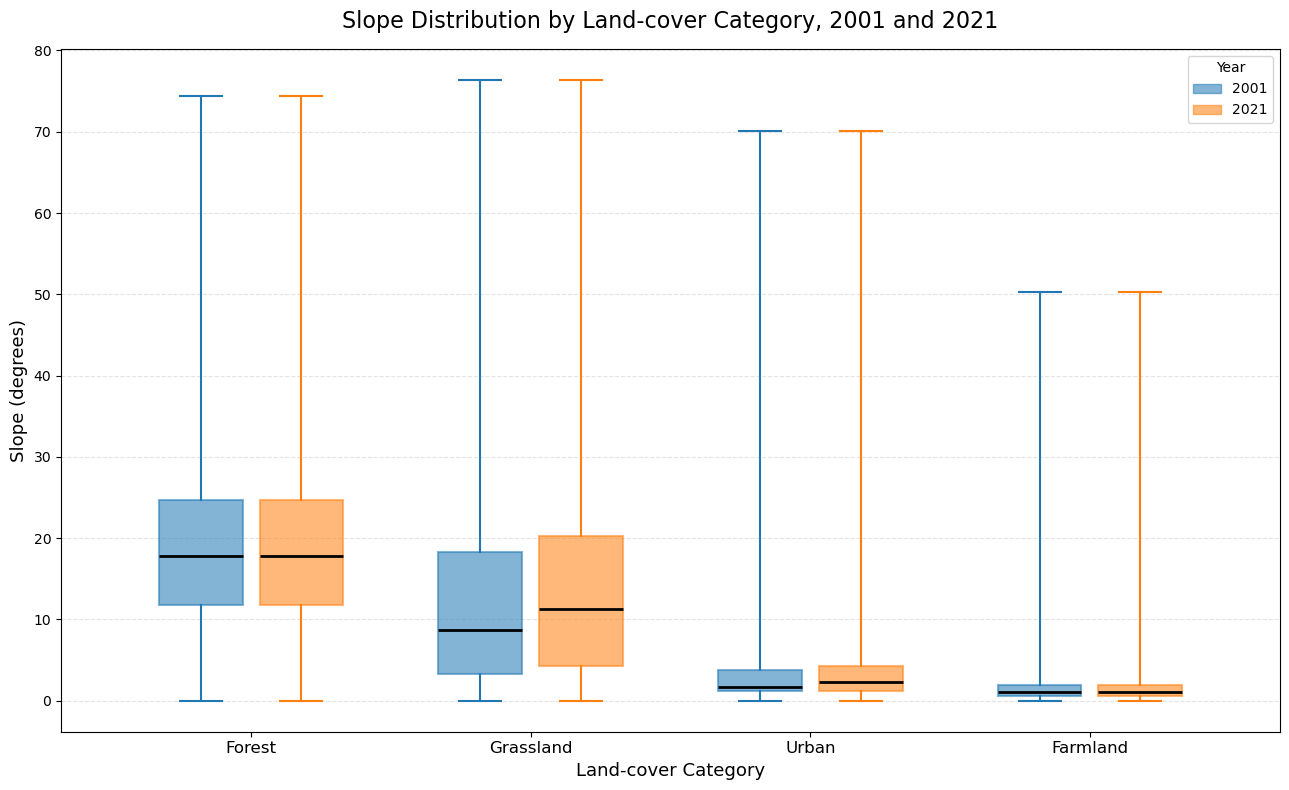

In [65]:
# ============================================================
# Draw and save slope box plots
# ============================================================

import matplotlib.pyplot as plt
from matplotlib.patches import Patch

fig, ax = plt.subplots(figsize=(13, 8))

boxplot_artists = ax.bxp(
    slope_boxplot_data,
    positions=slope_boxplot_positions,
    widths=0.30,
    patch_artist=True,
    showfliers=False
)

year_colors = {
    2001: 'C0',
    2021: 'C1'
}

# Color boxes
for box, year in zip(
    boxplot_artists['boxes'],
    slope_boxplot_years
):
    box.set_facecolor(year_colors[year])
    box.set_edgecolor(year_colors[year])
    box.set_alpha(0.55)
    box.set_linewidth(1.5)

# Median lines
for median in boxplot_artists['medians']:
    median.set_color('black')
    median.set_linewidth(2)

# Whiskers and caps
for index, year in enumerate(slope_boxplot_years):

    artists = [
        boxplot_artists['whiskers'][index * 2],
        boxplot_artists['whiskers'][index * 2 + 1],
        boxplot_artists['caps'][index * 2],
        boxplot_artists['caps'][index * 2 + 1]
    ]

    for artist in artists:
        artist.set_color(year_colors[year])
        artist.set_linewidth(1.5)

# X axis
ax.set_xticks(
    list(category_positions.values())
)

ax.set_xticklabels(
    category_order,
    fontsize=12
)

# Axis labels
ax.set_xlabel(
    'Land-cover Category',
    fontsize=13
)

ax.set_ylabel(
    'Slope (degrees)',
    fontsize=13
)

# Title
ax.set_title(
    'Slope Distribution by Land-cover Category, 2001 and 2021',
    fontsize=16,
    pad=15
)

# Grid
ax.grid(
    axis='y',
    linestyle='--',
    alpha=0.35
)

# Legend
legend_handles = [
    Patch(
        facecolor=year_colors[2001],
        edgecolor=year_colors[2001],
        alpha=0.55,
        label='2001'
    ),
    Patch(
        facecolor=year_colors[2021],
        edgecolor=year_colors[2021],
        alpha=0.55,
        label='2021'
    )
]

ax.legend(
    handles=legend_handles,
    title='Year'
)

fig.tight_layout()

fig.savefig(
    'landcover_slope_boxplot_2001_2021.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()